In [8]:
import cv2
import numpy as np
import imutils
import easyocr
from matplotlib import pyplot as pl

In [9]:
img = cv2.imread('../data/images/image.png')

In [10]:
def open_photo(photo):
    cv2.imshow('Result', photo)
    cv2.waitKey(0)

In [20]:
def open_photo_plot(photo):
    photo_rgb = cv2.cvtColor(photo, cv2.COLOR_BGR2RGB)
    pl.imshow(photo_rgb)
    pl.axis('off')
    pl.show()

In [11]:
def rotate(image, angle):
    height, width = image.shape[:2]
    point = (width // 2, height // 2)

    mat = cv2.getRotationMatrix2D(point, angle, 1)
    return cv2.warpAffine(image, mat, (width, height))

In [12]:
def transform(img_param, x, y):
    mat = np.float32([[1, 0, x], [0, 1, y]])
    return cv2.warpAffine(img_param, mat, (img_param.shape[1], img_param.shape[0]))

## Learning Python OpenCV / Lesson #2 – Working with Images and Videos

In [5]:
open_photo(img)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

-1

In [ ]:
img.shape

(1080, 1920, 3)

In [ ]:
# proportional resizing
reduction_factor = 2
h = img.shape[0] / 2
w = h * (img.shape[1] / img.shape[0])
print(h:=int(h), w:=int(w))
new_img_proportional_resizing = cv2.resize(img, (
    w,
    h, 
))
open_photo(new_img_proportional_resizing)

368 684


-1

In [ ]:
# proportional resizing 2
# arbitrary resizing
new_img_arbitrary_resizing = cv2.resize(img, (
    300,
    500, 
))
open_photo(new_img_arbitrary_resizing)

-1

In [ ]:
reduction_factor = 3
new_img_proportional_resizing = cv2.resize(img, (
    img.shape[1] // reduction_factor,
    img.shape[0] // reduction_factor, 
))
open_photo(new_img_proportional_resizing)

-1

In [ ]:
# cropped image
cropped_img = img[0:200, 0:300]
open_photo(cropped_img)

-1

In [ ]:
# gaussian blur
gaussian_blur_img = cv2.GaussianBlur(img, (19, 19), 0)

open_photo(gaussian_blur_img)

-1

In [ ]:
gaussian_blur_img_cvt = cv2.cvtColor(gaussian_blur_img, cv2.COLOR_BGR2GRAY) 

open_photo(gaussian_blur_img_cvt)

-1

In [ ]:
gaussian_blur_img_cvt_canny = cv2.Canny(gaussian_blur_img_cvt, 90, 90)

open_photo(gaussian_blur_img_cvt_canny)

-1

In [ ]:
kernel = np.ones((5, 5), np.uint8)
print(f'kernel: \n{kernel}')

gaussian_blur_img_cvt_canny_dilate = cv2.dilate(gaussian_blur_img_cvt_canny, kernel=kernel, iterations=2)

open_photo(gaussian_blur_img_cvt_canny_dilate)

kernel: 
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


-1

In [ ]:
gaussian_blur_img_cvt_canny_dilate_erode = cv2.erode(gaussian_blur_img_cvt_canny, kernel=kernel, iterations=2)

open_photo(gaussian_blur_img_cvt_canny_dilate)

-1

## Learning Python OpenCV / Lesson #3 – Creating Objects and Outputting Information

In [4]:
photo = np.zeros((300, 300, 3), dtype='uint8')

In [5]:
photo

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(300, 300, 3), dtype=uint8)

In [4]:
open_photo(photo)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

-1

In [ ]:
# RGB - standart
# BGR - OpenCV format
photo[:] = 255, 45, 78

In [7]:
open_photo(photo)

-1

In [ ]:
# RGB - standart
# BGR - OpenCV format
photo[:] = 175, 105, 255

In [9]:
open_photo(photo)

-1

In [ ]:
# RGB - standart
# BGR - OpenCV format
photo[:] = 255, 105, 175

In [11]:
open_photo(photo)

-1

In [14]:
# RGB - standart
# BGR - OpenCV format
photo[:] = 255, 255, 255
photo[150:200, 150:200] = 255, 105, 175

In [15]:
open_photo(photo)

-1

In [6]:
# RGB - standart
# BGR - OpenCV format
photo[:] = 255, 255, 255
cv2.rectangle(photo, (50, 70), (100, 100), (255, 105, 175), thickness=3)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [7]:
open_photo(photo)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

In [8]:
# RGB - standart
# BGR - OpenCV format
photo[:] = 255, 255, 255
cv2.rectangle(photo, (50, 70), (100, 100), (255, 105, 175), thickness=cv2.FILLED)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [9]:
open_photo(photo)

In [ ]:
# RGB - standart
# BGR - OpenCV format
cv2.line(photo, (0, 0), (photo.shape[1], photo.shape[0]), (255, 234, 175), thickness=3)

array([[[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]]

In [13]:
open_photo(photo)

In [16]:
# RGB - standart
# BGR - OpenCV format
cv2.line(photo, (150, 0), (0, photo.shape[0]), (255, 200, 100), thickness=3)
cv2.line(photo, (0, 150), (photo.shape[1], 0), (255, 200, 100), thickness=3)

array([[[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       ...,

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]]

In [17]:
open_photo(photo)

In [20]:
# RGB - standart
# BGR - OpenCV format
cv2.line(photo, (150, 0), (150, photo.shape[0]), (0, 255, 0), thickness=3)
cv2.line(photo, (0, 150), (photo.shape[1], 150), (0, 200, 0), thickness=3)

array([[[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       ...,

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]]

In [22]:
open_photo(photo)

In [31]:
cv2.circle(photo, (photo.shape[1] // 2, photo.shape[0] // 2), 50, (255, 3, 238), thickness=3)

array([[[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       ...,

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]]

In [32]:
open_photo(photo)

In [33]:
text_on_photo = photo.copy()
cv2.putText(text_on_photo, 'A V S', (
    text_on_photo.shape[1] // 2 - 50,
    text_on_photo.shape[0] // 2 - 50,
    ),
    cv2.FONT_HERSHEY_TRIPLEX,
    1,
    (0, 0, 200),
)

array([[[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       [[255, 234, 175],
        [255, 234, 175],
        [255, 234, 175],
        ...,
        [255, 200, 100],
        [255, 200, 100],
        [255, 200, 100]],

       ...,

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]],

       [[255, 200, 100],
        [255, 200, 100],
        [255, 200, 100],
        ...,
        [255, 234, 175],
        [255, 234, 175],
        [255, 234, 175]]

In [34]:
open_photo(text_on_photo)

## Learning Python OpenCV / Lesson #4 – Image Transformation Functions

In [78]:
cap = cv2.VideoCapture('../data/videos/VID_408.mp4')

In [12]:
success, img = cap.read()

In [13]:
type(img)

numpy.ndarray

In [15]:
open_photo(img)
success

True

In [79]:
success = True
while True:
    success, img = cap.read()
    # if not success:
    #     break
    img = cv2.GaussianBlur(img, (9, 9), 0)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img = cv2.Canny(img, 30, 30)

    kernel = np.ones((5, 5), np.uint8)
    img = cv2.dilate(img, kernel, iterations=1)
    
    img = cv2.erode(img, kernel, iterations=1)

    cv2.imshow('Result', img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/smooth.dispatch.cpp:618: error: (-215:Assertion failed) !_src.empty() in function 'GaussianBlur'


### Working with pictures

In [81]:
img_vertical_flip = cv2.flip(img, 1)
open_photo(img_vertical_flip)

In [82]:
img_horizontal_flip = cv2.flip(img, 0)
open_photo(img_horizontal_flip)

In [84]:
img_full_flip = cv2.flip(img, -1)
open_photo(img_full_flip)

In [85]:
returned_img = cv2.flip(img_full_flip, -1)
open_photo(returned_img)

In [11]:
rotated_img_30 = rotate(img, 30)
open_photo(rotated_img_30)

In [12]:
rotated_img_90 = rotate(img, 90)
open_photo(rotated_img_90)

In [13]:
rotated_img_180 = rotate(img, 180)
open_photo(rotated_img_180)

In [14]:
rotated_img_m90 = rotate(img, -90)
open_photo(rotated_img_m90)

In [7]:
img_transform = transform(img, 30, 200)
open_photo(img_transform)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

In [ ]:
img_transform = transform(img, -30, -100)
open_photo(img_transform)

In [14]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
open_photo(img_gray)

In [15]:
img_gray_gaussianblur = cv2.GaussianBlur(img_gray, (5, 5), 0)
open_photo(img_gray_gaussianblur)

In [16]:
img_gray_gaussianblur_canny = cv2.Canny(img_gray_gaussianblur, 100, 140)
open_photo(img_gray_gaussianblur_canny)

In [23]:
con, hir = cv2.findContours(img_gray_gaussianblur_canny, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
con

(array([[[307, 733]],
 
        [[306, 734]],
 
        [[306, 735]],
 
        [[307, 734]],
 
        [[308, 733]],
 
        [[309, 733]],
 
        [[310, 734]],
 
        [[310, 735]],
 
        [[310, 734]],
 
        [[310, 733]],
 
        [[309, 733]],
 
        [[308, 733]]], dtype=int32),
 array([[[208, 733]],
 
        [[207, 734]],
 
        [[206, 734]],
 
        [[207, 734]],
 
        [[208, 733]],
 
        [[209, 733]],
 
        [[210, 733]],
 
        [[211, 733]],
 
        [[212, 733]],
 
        [[213, 733]],
 
        [[214, 733]],
 
        [[215, 733]],
 
        [[216, 733]],
 
        [[217, 733]],
 
        [[218, 733]],
 
        [[217, 733]],
 
        [[216, 733]],
 
        [[215, 733]],
 
        [[214, 733]],
 
        [[213, 733]],
 
        [[212, 733]],
 
        [[211, 733]],
 
        [[210, 733]],
 
        [[209, 733]]], dtype=int32),
 array([[[242, 730]],
 
        [[241, 731]],
 
        [[240, 731]],
 
        [[239, 731]],
 
        [[238,

In [24]:
hir

array([[[  1,  -1,  -1,  -1],
        [  2,   0,  -1,  -1],
        [  3,   1,  -1,  -1],
        ...,
        [689, 687,  -1,  -1],
        [690, 688,  -1,  -1],
        [ -1, 689,  -1,  -1]]], shape=(1, 691, 4), dtype=int32)

In [41]:
new_img = np.zeros(img.shape, dtype='uint8')
new_img

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(736, 1368, 3), dtype=uint8)

In [42]:
new_img_drawcontours = new_img.copy()
open_photo(new_img_drawcontours)

In [44]:
cv2.drawContours(new_img_drawcontours, con, -1, (0, 230, 0), 1)
open_photo(new_img_drawcontours)

## Learning Python OpenCV / Lesson #5 – Color Formats

In [8]:
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
open_photo(img_hsv)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

In [12]:
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
open_photo(img_lab)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

In [13]:
img_lab

array([[[ 33, 127, 126],
        [ 18, 126, 125],
        [ 15, 126, 126],
        ...,
        [ 14, 128, 126],
        [ 15, 128, 126],
        [ 12, 130, 126]],

       [[ 32, 127, 125],
        [ 18, 126, 125],
        [ 15, 126, 126],
        ...,
        [ 12, 128, 126],
        [ 15, 128, 126],
        [ 12, 128, 126]],

       [[ 32, 127, 126],
        [ 17, 126, 125],
        [ 14, 126, 126],
        ...,
        [ 14, 128, 126],
        [ 15, 128, 126],
        [ 12, 128, 126]],

       ...,

       [[146, 125, 106],
        [141, 124, 100],
        [146, 125,  95],
        ...,
        [ 11, 128, 125],
        [ 12, 128, 125],
        [ 15, 126, 125]],

       [[148, 125, 106],
        [143, 124, 100],
        [147, 125,  95],
        ...,
        [ 12, 126, 126],
        [ 12, 128, 125],
        [ 15, 126, 125]],

       [[150, 125, 106],
        [145, 124,  99],
        [147, 126,  94],
        ...,
        [ 12, 126, 126],
        [ 12, 126, 125],
        [ 15, 126, 125]]

In [14]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
open_photo(img_rgb)

In [15]:
r, g, b = cv2.split(img_rgb)

In [16]:
open_photo(r)

In [17]:
open_photo(g)

In [18]:
open_photo(b)

In [19]:
img_rgb_merge = cv2.merge([r, g, b])
open_photo(img_rgb_merge)

In [21]:
img_rgb_merge = cv2.merge([b, g, r])
open_photo(img_rgb_merge)

## Learning Python OpenCV / Lesson #6 – Bitwise Operations and Masks

In [10]:
img_zeros = np.zeros((350, 350), dtype='uint8')
open_photo(img_zeros)

In [11]:
img_circle = cv2.circle(img_zeros.copy(), (125, 125), 50, 255, -1)
open_photo(img_circle)

In [ ]:
img_square = cv2.rectangle(img_zeros.copy(), (125, 125), (250, 350), 255, -1)
open_photo(img_square)

In [15]:
img_bitwise_and = cv2.bitwise_and(img_circle, img_square)
open_photo(img_bitwise_and)

In [16]:
img_bitwise_or = cv2.bitwise_or(img_circle, img_square)
open_photo(img_bitwise_or)

In [17]:
img_bitwise_xor = cv2.bitwise_xor(img_circle, img_square)
open_photo(img_bitwise_xor)

In [ ]:
img_bitwise_not = cv2.bitwise_not(img_circle)
open_photo(img_bitwise_not)

In [20]:
photo = img.copy()
photo_zeros = np.zeros(photo.shape[:2], dtype='uint8')
open_photo(photo_zeros)

In [23]:
photo_circle = cv2.circle(photo_zeros.copy(), (125, 125), 50, 255, -1)
open_photo(photo_circle)

In [24]:
photo_square = cv2.rectangle(photo_zeros.copy(), (125, 125), (250, 350), 255, -1)
open_photo(photo_square)

In [26]:
photo_bitwise_and = cv2.bitwise_and(photo, photo, mask=photo_square)
open_photo(photo_bitwise_and)

In [ ]:
photo_bitwise_and = cv2.bitwise_and(photo, photo, mask=cv2.bitwise_or(photo_circle, photo_square))
open_photo(photo_bitwise_and)

In [28]:
photo_bitwise_and1 = cv2.bitwise_and(photo, photo, mask=cv2.bitwise_not(cv2.bitwise_or(photo_circle, photo_square)))
open_photo(photo_bitwise_and1)

## Learning Python OpenCV / Lesson #7 – Face Recognition

In [7]:
face1 = cv2.imread('../data/images/faces/face1.jpg')
open_photo(face1)

QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/artem/development/ml/opencv_gosha_dudar/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.githu

In [9]:
face1_gray = cv2.cvtColor(face1, cv2.COLOR_BGR2GRAY)
open_photo(face1_gray)

In [10]:
faces = cv2.CascadeClassifier('../data/opencv/haarcascade_frontalface_default.xml')
faces

< cv2.CascadeClassifier 0x7cd6d495e2f0>

In [13]:
results = faces.detectMultiScale(face1_gray, scaleFactor=2, minNeighbors=3)
results

array([[ 36,  44,  96,  96],
       [520,  45,  96,  96],
       [ 36, 362,  96,  96],
       [197,  46,  96,  96],
       [ 40, 206,  96,  96],
       [196, 364,  96,  96],
       [361,  46,  96,  96],
       [360, 364,  96,  96],
       [196, 200,  96,  96],
       [521, 365,  96,  96],
       [360, 205,  96,  96],
       [523, 206,  96,  96]], dtype=int32)

In [15]:
results = faces.detectMultiScale(face1, scaleFactor=2, minNeighbors=3)
results

array([[ 36,  44,  96,  96],
       [520,  45,  96,  96],
       [197,  46,  96,  96],
       [361,  46,  96,  96],
       [ 40, 206,  96,  96],
       [196, 200,  96,  96],
       [ 36, 362,  96,  96],
       [196, 364,  96,  96],
       [360, 205,  96,  96],
       [360, 364,  96,  96],
       [523, 206,  96,  96],
       [521, 365,  96,  96]], dtype=int32)

In [19]:
face1_result = face1.copy()
for (x, y, w, h) in results:
    cv2.rectangle(face1_result, (x, y), (x + w, y + h), (0, 0, 255), thickness=3)
open_photo(face1_result)

In [ ]:
face1_result = face1.copy()
for (x, y, w, h) in results:
    cv2.rectangle(face1_result, (x, y), (x + w, y + h), (0, 0, 255), thickness=3)
open_photo(face1_result)

In [20]:
face2 = cv2.imread('../data/images/faces/face2.jpg')
open_photo(face2)

In [53]:
results = faces.detectMultiScale(face2, scaleFactor=2.774, minNeighbors=3)
results

array([[413,  68, 185, 185],
       [769,  79, 185, 185]], dtype=int32)

In [54]:
face_result = face2.copy()
for (x, y, w, h) in results:
    cv2.rectangle(face_result, (x, y), (x + w, y + h), (0, 0, 255), thickness=3)
open_photo(face_result)

In [56]:
face3 = cv2.imread('../data/images/faces/face3.png')
open_photo(face3)

In [59]:
results = faces.detectMultiScale(face3, scaleFactor=3, minNeighbors=3)
results

array([[ 158,  178,  216,  216],
       [ 538,  175,  216,  216],
       [1035,  157,  216,  216],
       [1410,  162,  216,  216],
       [ 156,  869,  216,  216],
       [ 528,  868,  216,  216],
       [1388,  853,  216,  216],
       [1014,  858,  216,  216]], dtype=int32)

In [60]:
face_result = face3.copy()
for (x, y, w, h) in results:
    cv2.rectangle(face_result, (x, y), (x + w, y + h), (0, 0, 255), thickness=3)
open_photo(face_result)

## Learning Python OpenCV / Lesson #8 – Recognizing License Plates and Reading Them

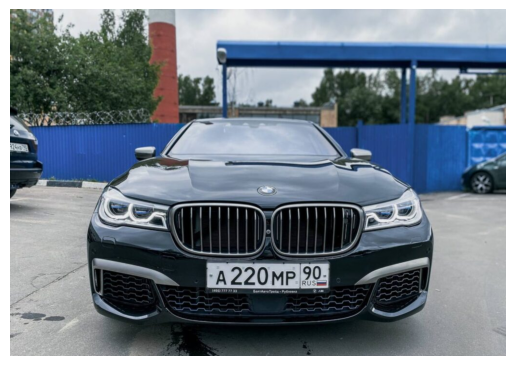

In [21]:
img_car = cv2.imread('../data/images/license_plates/license_plate1.jpg')
open_photo_plot(img_car)

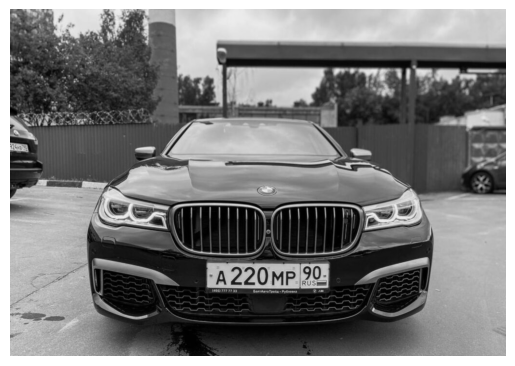

In [22]:
img_car_gray = cv2.cvtColor(img_car, cv2.COLOR_BGR2GRAY)
open_photo_plot(img_car_gray)

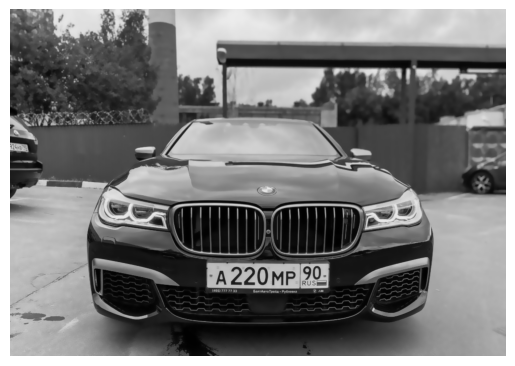

In [23]:
img_car_gray_filter = cv2.bilateralFilter(img_car_gray, 11, 15, 15)
open_photo_plot(img_car_gray_filter)

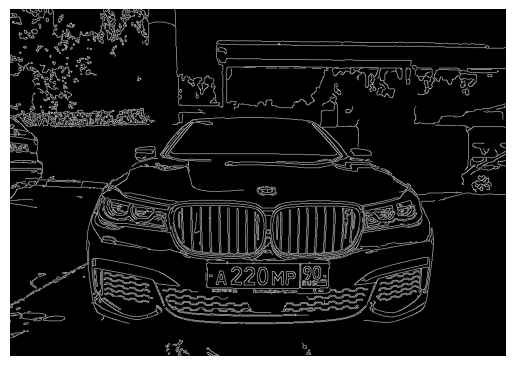

In [24]:
img_car_gray_filter_canny = cv2.Canny(img_car_gray_filter, 30, 200)
open_photo_plot(img_car_gray_filter_canny)